In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./outputs/human_cytokine_dict_mini.csv")

In [3]:
df.columns

Index(['Unnamed: 0', 'index', 'gene', 'log_fc', 'logCPM', 'F', 'p_value',
       'adj_p_value', 'contrast', 'celltype', 'cytokine', 'num_donors',
       'median_num_cells_pbs', 'median_num_cells_cytokine',
       'mean_num_cells_pbs', 'mean_num_cells_cytokine', 'min_num_cells_pbs',
       'min_num_cells_cytokine', 'max_num_cells_pbs', 'max_num_cells_cytokine',
       'num_DE_pbs_wells', 'well_biased'],
      dtype='object')

In [4]:
df["truth"] = (
    (df["adj_p_value"] < 0.05) &
    (df["log_fc"] > 0)
).astype(int)

In [5]:
final_df = df[["cytokine", "celltype", "truth"]]

In [6]:
summary = (
    final_df.groupby(["celltype", "cytokine"], as_index=False)["truth"]
      .sum()
)

In [7]:
summary

,celltype,cytokine,truth
0,B_cell,4-1BBL,7
1,B_cell,ADSF,10
2,B_cell,APRIL,6
3,B_cell,BAFF,77
4,B_cell,C5a,26
...,...,...,...
1904,pDC,TNF-alpha,61
1905,pDC,TRAIL,12
1906,pDC,TSLP,9
1907,pDC,TWEAK,3


In [8]:
heatmap = summary.pivot(
    index="celltype",
    columns="cytokine",
    values="truth"
).fillna(0)


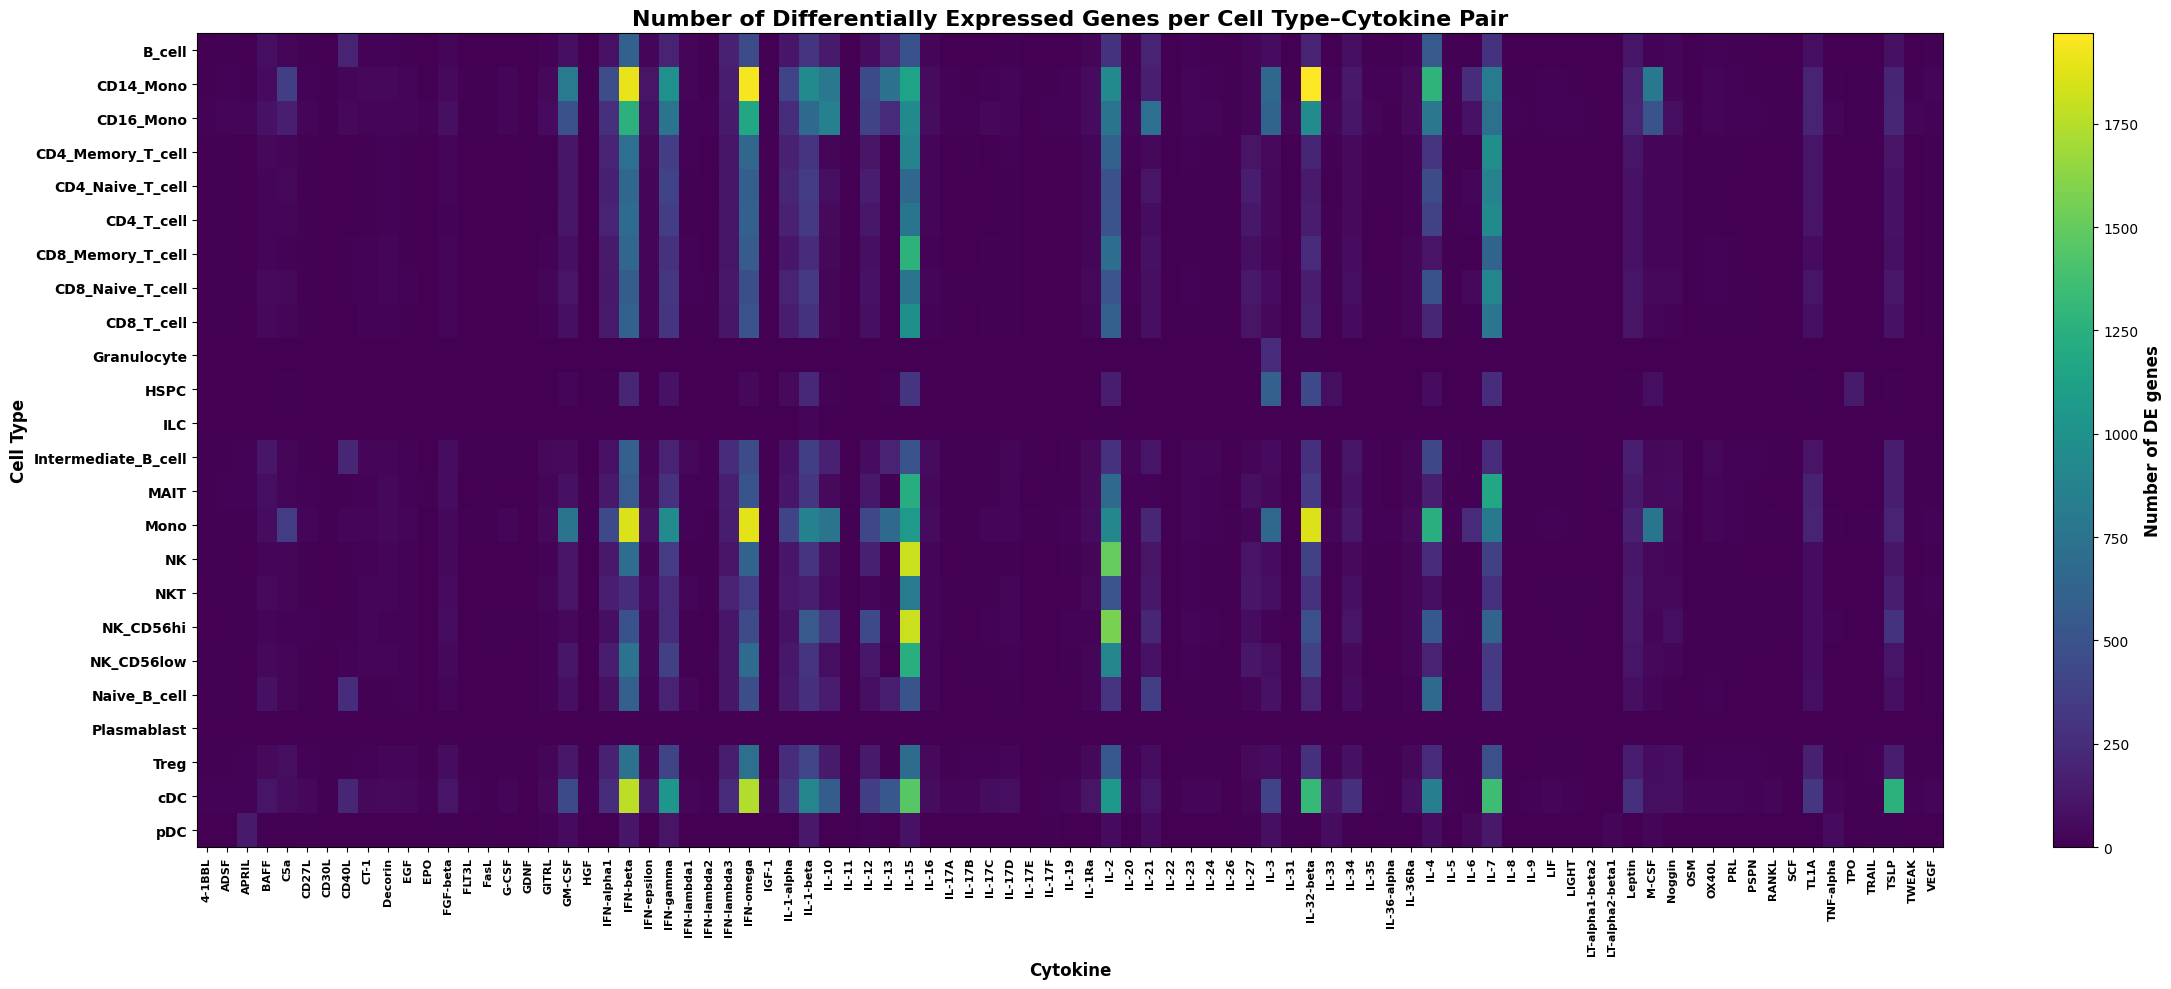

In [9]:
plt.figure(figsize=(24, 10))
plt.imshow(heatmap, aspect="auto", interpolation="nearest")
cbar = plt.colorbar(label="Number of DE genes")
cbar.set_label("Number of DE genes", fontsize=12, fontweight="bold")

plt.xticks(
    range(len(heatmap.columns)),
    heatmap.columns,
    rotation=90,
    fontsize=8,
    fontweight="bold"
)

plt.yticks(
    range(len(heatmap.index)),
    heatmap.index,
    fontsize=10,
    fontweight="bold"
)

plt.xlabel("Cytokine", fontsize=12, fontweight="bold")
plt.ylabel("Cell Type", fontsize=12, fontweight="bold")
plt.title(
    "Number of Differentially Expressed Genes per Cell Type–Cytokine Pair",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

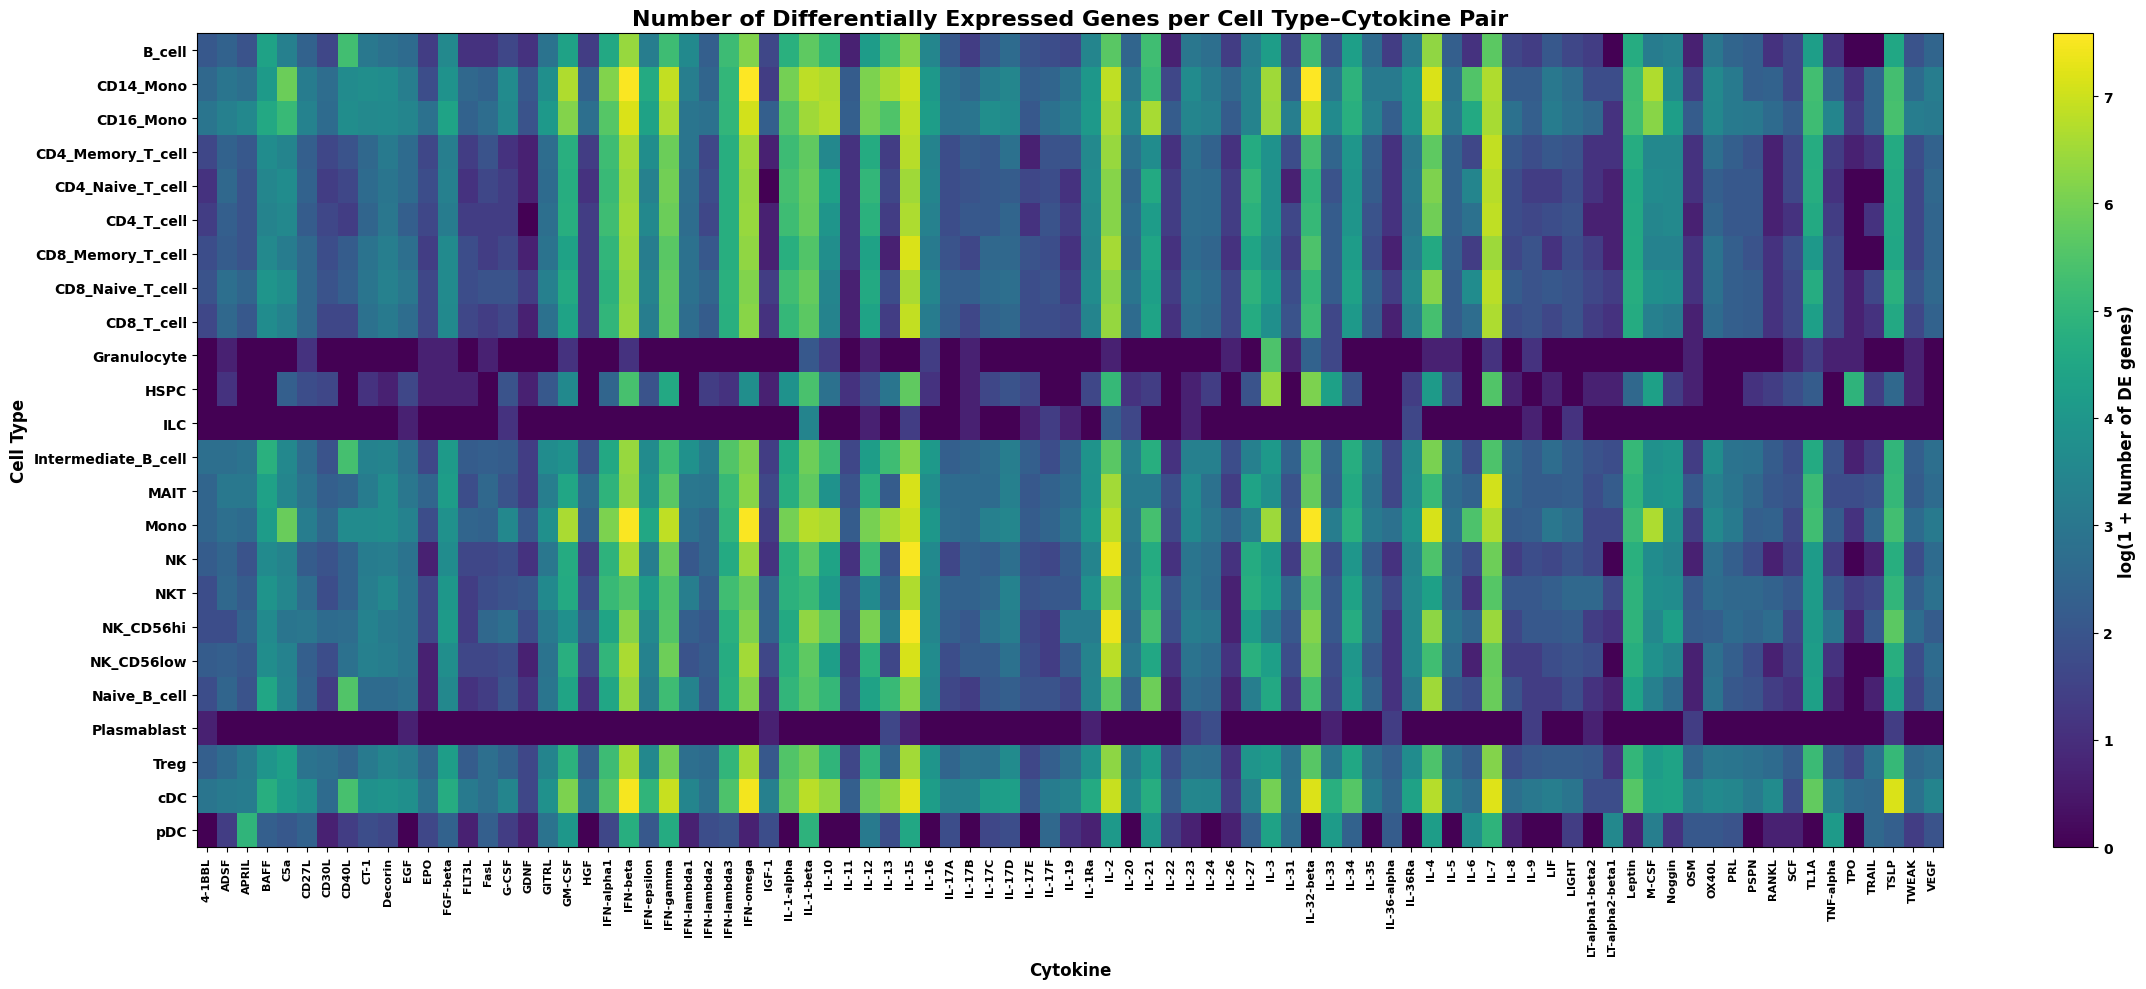

In [10]:


plt.figure(figsize=(24, 10))

im = plt.imshow(
    np.log1p(heatmap),   # log(1 + x) transform
    aspect="auto",
    interpolation="nearest",
    cmap="viridis"
)

cbar = plt.colorbar(im)
cbar.set_label("log(1 + Number of DE genes)", fontsize=12, fontweight="bold")
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight("bold")

plt.xticks(
    range(len(heatmap.columns)),
    heatmap.columns,
    rotation=90,
    fontsize=8,
    fontweight="bold"
)

plt.yticks(
    range(len(heatmap.index)),
    heatmap.index,
    fontsize=10,
    fontweight="bold"
)

plt.xlabel("Cytokine", fontsize=12, fontweight="bold")
plt.ylabel("Cell Type", fontsize=12, fontweight="bold")
plt.title(
    "Number of Differentially Expressed Genes per Cell Type–Cytokine Pair",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig("heatmap_log1p.png", dpi=300, bbox_inches="tight")
plt.show()

### Select the celltypes and cytokines that are prominent.

In [11]:
df = np.log1p(heatmap)

In [12]:
threshold = 5

cytokine_to_celltypes = {
    cytokine: set(df.index[df[cytokine] > threshold])
    for cytokine in df.columns
    if (df[cytokine] > threshold).any()
}

print(cytokine_to_celltypes)

{'C5a': {'Mono', 'CD14_Mono', 'CD16_Mono'}, 'CD40L': {'Intermediate_B_cell', 'cDC', 'B_cell', 'Naive_B_cell'}, 'GM-CSF': {'cDC', 'Mono', 'CD14_Mono', 'CD16_Mono'}, 'IFN-alpha1': {'CD4_Memory_T_cell', 'CD4_T_cell', 'CD4_Naive_T_cell', 'NK_CD56low', 'CD14_Mono', 'NKT', 'Mono', 'CD16_Mono', 'cDC', 'Treg'}, 'IFN-beta': {'CD4_T_cell', 'NK_CD56low', 'CD14_Mono', 'NK_CD56hi', 'MAIT', 'NK', 'CD8_Memory_T_cell', 'Mono', 'cDC', 'B_cell', 'NKT', 'CD8_Naive_T_cell', 'Intermediate_B_cell', 'CD8_T_cell', 'Treg', 'CD4_Memory_T_cell', 'HSPC', 'CD4_Naive_T_cell', 'CD16_Mono', 'Naive_B_cell'}, 'IFN-gamma': {'CD4_T_cell', 'NK_CD56low', 'CD14_Mono', 'NK_CD56hi', 'MAIT', 'NK', 'CD8_Memory_T_cell', 'Mono', 'cDC', 'B_cell', 'NKT', 'CD8_Naive_T_cell', 'Intermediate_B_cell', 'CD8_T_cell', 'Treg', 'CD4_Memory_T_cell', 'CD4_Naive_T_cell', 'CD16_Mono', 'Naive_B_cell'}, 'IFN-lambda3': {'B_cell', 'CD14_Mono', 'NKT', 'Mono', 'MAIT', 'Intermediate_B_cell', 'cDC'}, 'IFN-omega': {'CD4_T_cell', 'NK_CD56low', 'CD14_Mono'

In [13]:
table = pd.DataFrame({
    k: pd.Series(sorted(v))
    for k, v in cytokine_to_celltypes.items()
})

#table.to_csv("important_cytokines_celltypes.csv", index=False)

In [14]:
dct_hucira_to_cc = {
    'Intermediate_B_cell' : 'B Intermediate/Memory', 
    'NKT' : 'NKT', 
    'CD8_Memory_T_cell' : 'CD8 Memory', 
    'NK_CD56low' : "", ### NA
    'CD16_Mono' : 'CD16 Mono', 
    'NK_CD56hi' : 'NK CD56bright',
    'CD8_Naive_T_cell' : 'CD8 Naive',
    'pDC' : 'pDC', 
    'ILC' : "ILC", # nan
    'MAIT' : "MAIT",
    'Naive_B_cell' : "B Naive",
    'CD4_Naive_T_cell' : "CD4 Naive",
    'Treg' : "Treg",
    'Plasmablast' : "Plasmablast", #nan
    'Granulocyte' : "", ### NA
    'B_cell' : "", ### NA
    'CD4_T_cell' : "", ### NA
    'HSPC' : "HSPC",
    'CD8_T_cell' : "", ### NA
    'CD14_Mono' : 'CD14 Mono',
    'cDC'  : "cDC",
    'CD4_Memory_T_cell' : 'CD4 Memory',
    'NK' : "NK",
    'Mono' : "" ### NA
}

In [15]:
import pandas as pd

# Map names
table = table.apply(lambda col: col.map(lambda x: dct_hucira_to_cc.get(x, "")))

# Remove empty strings and re-pack each column
table = pd.DataFrame({
    col: table[col][table[col] != ""].reset_index(drop=True)
    for col in table.columns
})

### Map the cytokine names to the gene names
df = pd.read_excel("cytokine_info.xlsx")

# mapping: name -> gene
name_to_gene = dict(zip(df["name"], df["gene"]))
table.columns = table.columns.map(lambda x: name_to_gene.get(x, x))


In [16]:
table = table.loc[:, table.count() > 3]

In [17]:
table.to_csv("important_cytokines_celltypes.csv", index = False)

In [18]:
print (table.columns)

Index(['IFNA1', 'IFNB1', 'IFNG', 'IFNL3', 'IFNW1', 'IL1A', 'IL1B', 'IL10',
       'IL12A, IL12B', 'IL13', 'IL15', 'IL2', 'IL21', 'IL3', 'IL32', 'IL4',
       'IL7', 'LEP', 'TNFSF15', 'TSLP'],
      dtype='object')


In [19]:
table

,IFNA1,IFNB1,IFNG,IFNL3,IFNW1,IL1A,IL1B,IL10,"IL12A, IL12B",IL13,IL15,IL2,IL21,IL3,IL32,IL4,IL7,LEP,TNFSF15,TSLP
0,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono,CD14 Mono
1,CD16 Mono,CD16 Mono,CD16 Mono,B Intermediate/Memory,CD16 Mono,CD16 Mono,CD16 Mono,CD16 Mono,CD16 Mono,CD16 Mono,CD16 Mono,CD16 Mono,CD16 Mono,CD16 Mono,CD16 Mono,CD16 Mono,CD16 Mono,CD16 Mono,CD16 Mono,CD16 Mono
2,CD4 Memory,CD4 Memory,CD4 Memory,MAIT,CD4 Memory,CD4 Memory,CD4 Memory,B Intermediate/Memory,CD4 Naive,B Intermediate/Memory,CD4 Memory,CD4 Memory,NK CD56bright,HSPC,CD4 Memory,CD4 Memory,CD4 Memory,B Intermediate/Memory,MAIT,MAIT
3,CD4 Naive,CD4 Naive,CD4 Naive,NKT,CD4 Naive,CD4 Naive,CD4 Naive,NK CD56bright,NK,B Naive,CD4 Naive,CD4 Naive,B Naive,cDC,CD8 Memory,CD4 Naive,CD4 Naive,Treg,Treg,NK CD56bright
4,NKT,CD8 Memory,CD8 Memory,cDC,CD8 Memory,CD8 Naive,CD8 Memory,B Naive,NK CD56bright,cDC,CD8 Memory,CD8 Memory,NaN,NaN,CD8 Naive,CD8 Naive,CD8 Memory,cDC,cDC,Treg
5,Treg,CD8 Naive,CD8 Naive,NaN,CD8 Naive,Treg,CD8 Naive,cDC,cDC,NaN,CD8 Naive,CD8 Naive,NaN,NaN,HSPC,B Intermediate/Memory,CD8 Naive,NaN,NaN,cDC
6,cDC,HSPC,B Intermediate/Memory,NaN,B Intermediate/Memory,cDC,HSPC,NaN,NaN,NaN,HSPC,HSPC,NaN,NaN,B Intermediate/Memory,MAIT,HSPC,NaN,NaN,NaN
7,NaN,B Intermediate/Memory,MAIT,NaN,MAIT,NaN,B Intermediate/Memory,NaN,NaN,NaN,B Intermediate/Memory,B Intermediate/Memory,NaN,NaN,MAIT,NK,B Intermediate/Memory,NaN,NaN,NaN
8,NaN,MAIT,NK,NaN,NK,NaN,MAIT,NaN,NaN,NaN,MAIT,MAIT,NaN,NaN,NK,NK CD56bright,MAIT,NaN,NaN,NaN
9,NaN,NK,NKT,NaN,NKT,NaN,NK,NaN,NaN,NaN,NK,NK,NaN,NaN,NKT,B Naive,NK,NaN,NaN,NaN
